# Pairwise / Group EIG vs covariance + LOBPCG

All three methods keep a d x d matrix and see the same batches:

- **Pairwise EIG** (`pairwise_eig.py`): greedy 2x2 Jacobi rotations on S = U^T C U.
- **Group EIG** (`group_eig.py`): greedy 2p x 2p block rotations on S.
- **Cov + LOBPCG** (`cov_lobpcg.py`): keeps C itself and, after every batch, runs a few
  LOBPCG iterations starting from the previous eigenvectors.

Data is centered with a running mean (see `center` below), so nothing uses the mean of the full stream.

In [2]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sla

import data as ds
import pairwise_eig
import group_eig
from cov_lobpcg import OnlineCovLOBPCG

In [3]:
# "yearprediction" | "gas_sensor" | "synthetic" | "glove300" | "har"
# "isolet" | "fashion_mnist" | "news20" | "cifar10"
DATASET = "synthetic"

P = 15
BATCH = 3000
MONITOR_ROWS = 2000
MAX_SAMPLES = 30000      # samples used from the stream
SEED = 0

# rotations per batch, scaled with d
PAIRWISE_ROT_PER_DIM = 2.0   # pairwise G = 2 d
GROUP_ROT_PER_DIM = 0.5      # group GG = 0.5 d / P  (one group step ~ P rotations)

# LOBPCG iterations per batch
LOBPCG_ITERS = 1

In [4]:
X_all = ds.load(DATASET)
rows = np.random.default_rng(SEED).permutation(X_all.shape[0])[:MONITOR_ROWS + MAX_SAMPLES]
A = np.asarray(X_all[rows], dtype=np.float64)

monitor = A[:MONITOR_ROWS].T                 # (d, 2000) held-out set
stream = A[MONITOR_ROWS:].T                  # (d, N)   samples are columns
batches = [stream[:, s:s + BATCH] for s in range(0, stream.shape[1], BATCH)]

d = stream.shape[0]
G = math.ceil(PAIRWISE_ROT_PER_DIM * d)
GROUP_G = math.ceil(GROUP_ROT_PER_DIM * d / P)

print(f"{DATASET}: d={d}, stream={stream.shape[1]}, batches={len(batches)}")
print(f"pairwise G={G}, group G={GROUP_G}, LOBPCG iters={LOBPCG_ITERS}")

synthetic: d=256, stream=30000, batches=10
pairwise G=512, group G=9, LOBPCG iters=1


Centering with a running mean. Each batch is centered with its own mean and one extra column
`sqrt(w) * (mu_old - mu_batch)` is appended, with `w = n_old * m / (n_old + m)`. Summing `z z^T`
over these columns gives exactly the centered covariance of all samples seen so far, so every
method can keep doing `C += Z Z^T` with raw sums.

In [5]:
class RunningMean:
    def __init__(self, d):
        self.n = 0
        self.mu = np.zeros(d)

    def center(self, X):
        m = X.shape[1]
        mu_b = X.mean(axis=1)
        Z = X - mu_b[:, None]
        if self.n > 0:
            w = self.n * m / (self.n + m)
            Z = np.hstack([Z, math.sqrt(w) * (self.mu - mu_b)[:, None]])
        self.mu = (self.n * self.mu + m * mu_b) / (self.n + m)
        self.n += m
        return Z


def evr(X, Q):
    R = X - Q @ (Q.T @ X)
    return 1.0 - (R ** 2).sum() / (X ** 2).sum()

In [6]:
def run(est, name):
    mean = RunningMean(d)
    times, evrs, samples = [], [], []
    t = 0.0
    for X in batches:
        t0 = time.perf_counter()
        est.partial_fit(mean.center(X))
        t += time.perf_counter() - t0

        Q = est.components_.T
        times.append(t)
        evrs.append(evr(monitor - mean.mu[:, None], Q))
        samples.append(mean.n)
    print(f"{name:14s} time = {t:7.3f}s   EVR = {evrs[-1]:.6f}")
    return np.array(samples), np.array(times), np.array(evrs)


results = {
    "Pairwise EIG": run(pairwise_eig.OnlineEIG(n=d, p=P, k_per_batch=G), "Pairwise EIG"),
    "Group EIG": run(group_eig.OnlineGroupEIG(n=d, p=P, k_per_batch=GROUP_G), "Group EIG"),
    "Cov + LOBPCG": run(OnlineCovLOBPCG(n=d, p=P, n_iter=LOBPCG_ITERS, seed=SEED), "Cov + LOBPCG"),
}

Pairwise EIG   time =   1.282s   EVR = 0.643150
Group EIG      time =   0.766s   EVR = 0.646251
Cov + LOBPCG   time =   0.235s   EVR = 0.646249


Reference: exact top-P eigenvectors of the full centered stream (offline, not timed).

In [7]:
Xc = stream - stream.mean(axis=1, keepdims=True)
_, V = sla.eigh(Xc @ Xc.T, subset_by_index=[d - P, d - 1])
evr_exact = evr(monitor - stream.mean(axis=1, keepdims=True), V)
print(f"exact PCA      EVR = {evr_exact:.6f}")

exact PCA      EVR = 0.646249


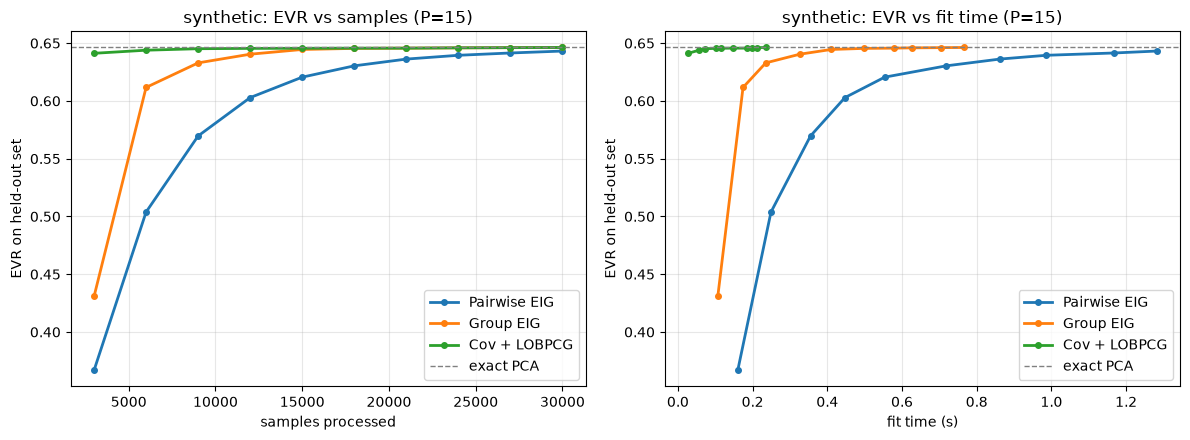

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for name, (samples, times, evrs) in results.items():
    ax1.plot(samples, evrs, "o-", lw=2, ms=4, label=name)
    ax2.plot(times, evrs, "o-", lw=2, ms=4, label=name)

for ax in (ax1, ax2):
    ax.axhline(evr_exact, color="gray", ls="--", lw=1, label="exact PCA")
    ax.set_ylabel("EVR on held-out set")
    ax.grid(alpha=0.3)
    ax.legend()

ax1.set_xlabel("samples processed")
ax2.set_xlabel("fit time (s)")
ax1.set_title(f"{DATASET}: EVR vs samples (P={P})")
ax2.set_title(f"{DATASET}: EVR vs fit time (P={P})")
plt.tight_layout()
plt.show()

Things to try:

- `LOBPCG_ITERS`: 1 is usually enough, more iterations cost one extra `C @ Q` each.
- `GROUP_ROT_PER_DIM` / `PAIRWISE_ROT_PER_DIM`: the rotation budget per batch. With only a few
  batches (har, isolet) the default group budget is too small for the first batch.
- `BATCH` and `P`: smaller batches or a larger P make LOBPCG's per-batch cost (one `C @ Q` per
  iteration, O(d^2 p)) matter more compared with the accumulation.